# Week 2: Task 2.1 — Overfitting Made Visible
This notebook demonstrates underfitting, optimal fitting, and overfitting using 
a noisy sine wave and polynomial regression.


In [18]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

In [19]:
# Generate noisy sine wave data
np.random.seed(42)

X = np.sort(np.random.rand(30)).reshape(-1, 1)
y = np.sin(1.5 * np.pi * X).ravel() + np.random.normal(0, 0.15, 30)

In [20]:
# Split into training and validation sets
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

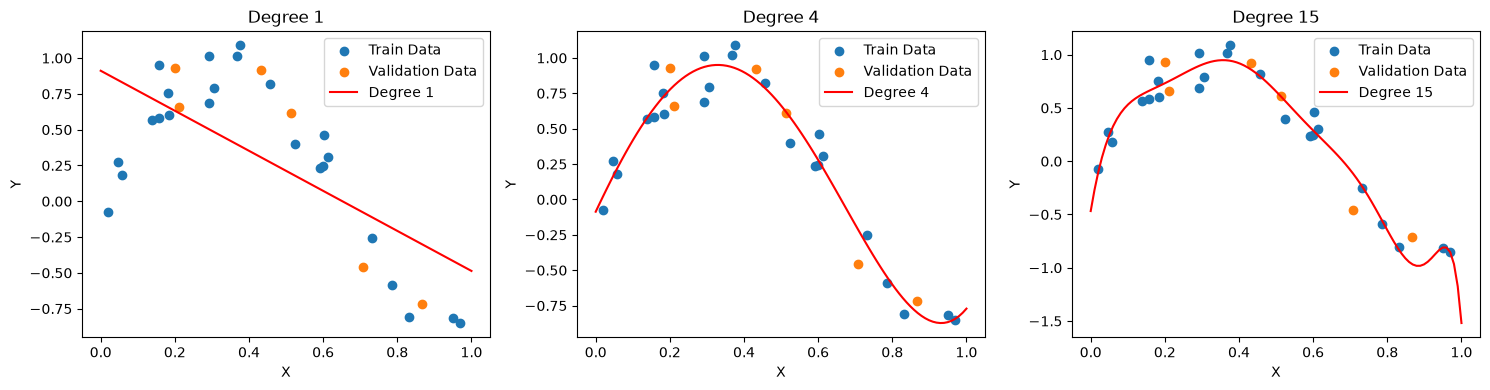

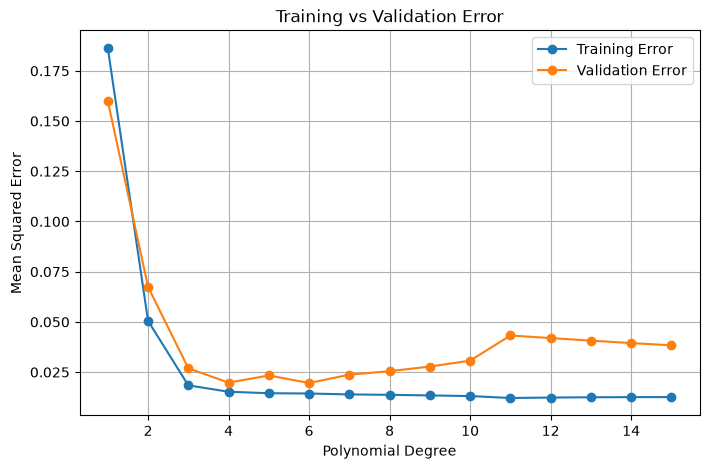

In [21]:
# Plot Polynomial Models
degrees = [1, 4, 15]

plt.figure(figsize=(15, 4))

X_plot = np.linspace(0, 1, 100).reshape(-1, 1)

for i, degree in enumerate(degrees):

    model = make_pipeline(
        PolynomialFeatures(degree),
        LinearRegression()
    )

    model.fit(X_train, y_train)

    y_plot = model.predict(X_plot)

    plt.subplot(1, 3, i + 1)
    plt.scatter(X_train, y_train, label="Train Data")
    plt.scatter(X_val, y_val, label="Validation Data")
    plt.plot(X_plot, y_plot, color="red", label=f"Degree {degree}")

    plt.title(f"Degree {degree}")
    plt.xlabel("X")
    plt.ylabel("Y")
    plt.legend()

plt.tight_layout()
plt.show()

# Training vs Validation Error

train_error = []
val_error = []

for degree in range(1, 16):

    model = make_pipeline(
        PolynomialFeatures(degree),
        LinearRegression()
    )

    model.fit(X_train, y_train)

    train_pred = model.predict(X_train)
    val_pred = model.predict(X_val)

    train_error.append(mean_squared_error(y_train, train_pred))
    val_error.append(mean_squared_error(y_val, val_pred))

plt.figure(figsize=(8, 5))

plt.plot(range(1, 16), train_error, marker="o", label="Training Error")
plt.plot(range(1, 16), val_error, marker="o", label="Validation Error")

plt.xlabel("Polynomial Degree")
plt.ylabel("Mean Squared Error")
plt.title("Training vs Validation Error")
plt.legend()
plt.grid(True)

plt.show()